# Optimización de hiperparámetros con Particle Swarm Optimization (PSO)

**Tema:** Uso de algoritmos de enjambre para hallar los mejores hiperparámetros de un modelo de aprendizaje de máquina (*Hyperparameter Tuning*).

**Ambiente:** Google Colab · Python 3 · scikit-learn · NumPy · Matplotlib

**Problema concreto:** clasificar dígitos manuscritos (dataset `digits`, 10 clases) con una **SVM de kernel RBF**, buscando los valores de `C` y `gamma` que maximicen la exactitud (*accuracy*) en validación cruzada.

---
### Contenido
1. Marco teórico: ¿qué es el *Hyperparameter Tuning*? y ¿por qué PSO?
2. Definición del problema y datos
3. Ciclo del algoritmo de enjambre (representación → inicialización → aptitud → comportamiento → evolución → finalización)
4. Implementación de PSO desde cero
5. Ejecución y resultados
6. Visualización del enjambre sobre el paisaje de aptitud
7. Comparación con *Grid Search* y *Random Search*
8. Evaluación final en datos de prueba
9. Conclusiones

## 1. Marco teórico

### 1.1 Parámetros vs. hiperparámetros
- **Parámetros**: valores que el modelo *aprende* de los datos durante el entrenamiento (p. ej. los pesos de una red neuronal, los vectores soporte de una SVM).
- **Hiperparámetros**: valores que el analista *fija antes* de entrenar y que controlan el comportamiento del aprendizaje (p. ej. `C` y `gamma` en una SVM, la profundidad máxima de un árbol, la tasa de aprendizaje, el número de neuronas).

El **Hyperparameter Tuning** (u optimización de hiperparámetros) consiste en encontrar la configuración de hiperparámetros $\lambda^*$ que maximiza el desempeño del modelo sobre datos no vistos:

$$\lambda^* = \arg\max_{\lambda \in \Lambda} \; \text{Score}\big(\text{Modelo}_\lambda,\; \text{CV}\big)$$

donde $\Lambda$ es el espacio de búsqueda y el *score* se estima con validación cruzada (CV) para no sobreajustar a una sola partición.

### 1.2 ¿Por qué es un problema difícil?
| Característica | Consecuencia |
|---|---|
| La función objetivo es una **caja negra** (hay que entrenar el modelo para evaluarla) | No hay gradiente disponible |
| Cada evaluación es **costosa** (entrenar + validar) | Hay que ser eficiente con el número de evaluaciones |
| El paisaje es **no convexo, con mesetas y ruido** | Los métodos locales se atascan |
| El espacio puede ser **mixto** (continuo, entero, categórico) | Requiere una codificación adecuada |

### 1.3 Enfoques comunes
- **Grid Search**: prueba todas las combinaciones de una malla. Crece exponencialmente con el número de hiperparámetros.
- **Random Search**: muestrea al azar; suele superar a la malla, pero no *aprende* de lo evaluado.
- **Optimización Bayesiana**: modela la función objetivo con un sustituto probabilístico.
- **Metaheurísticas / algoritmos de enjambre (PSO, ABC, ACO, etc.)**: población de candidatos que *comparten información* para explorar y explotar el espacio a la vez. **Este es el enfoque que usamos.**

### 1.4 Particle Swarm Optimization (PSO)
PSO (Kennedy y Eberhart, 1995) se inspira en el comportamiento social de bandadas de aves o bancos de peces. Cada **partícula** representa una solución candidata (una configuración de hiperparámetros) que se mueve por el espacio de búsqueda. Su movimiento combina tres influencias:

1. **Inercia**: tendencia a seguir en la dirección que llevaba.
2. **Componente cognitiva**: atracción hacia la mejor posición que ella misma ha encontrado (*pbest*).
3. **Componente social**: atracción hacia la mejor posición encontrada por todo el enjambre (*gbest*).

Ecuaciones de actualización para la partícula $i$ en la iteración $t$:

$$v_i^{t+1} = w\,v_i^{t} + c_1 r_1\,(pbest_i - x_i^{t}) + c_2 r_2\,(gbest - x_i^{t})$$

$$x_i^{t+1} = x_i^{t} + v_i^{t+1}$$

- $w$: peso de inercia (alto al inicio → exploración; bajo al final → explotación).
- $c_1, c_2$: coeficientes cognitivo y social.
- $r_1, r_2 \sim U(0,1)$: números aleatorios que aportan estocasticidad.

### 1.5 Ciclo del algoritmo de enjambre (mapeo a nuestro problema)

| Etapa | En este ejemplo |
|---|---|
| **1. Representación de la partícula** | Vector $x = [\log_{10} C,\ \log_{10}\gamma]$. Se busca en escala logarítmica porque `C` y `gamma` varían en órdenes de magnitud. |
| **2. Inicialización del enjambre** | 12 partículas con posiciones aleatorias uniformes dentro de los límites y velocidades aleatorias pequeñas. |
| **3. Función de aptitud** | Exactitud media en validación cruzada estratificada de 5 pliegues (**se maximiza**). |
| **4. Comportamiento de la partícula** | Actualización de velocidad y posición con inercia + *pbest* + *gbest*; se limita la velocidad y se recortan las posiciones a los límites. |
| **5. Evolución** | Se repite en cada iteración: evaluar → actualizar *pbest*/*gbest* → mover. El peso de inercia decrece linealmente. |
| **6. Finalización** | Se alcanza el máximo de iteraciones **o** no hay mejora del *gbest* durante `patience` iteraciones (parada temprana). |

## 2. Configuración del entorno y datos

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110

In [2]:
# Datos: 1797 imágenes de 8x8 píxeles (64 características), 10 clases (dígitos 0-9)
X, y = load_digits(return_X_y=True)

# Separamos un conjunto de PRUEBA que el optimizador NUNCA ve.
# La búsqueda de hiperparámetros solo usa el conjunto de entrenamiento (con CV).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
print(f"Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}")

# Validación cruzada estratificada fija (misma partición para todas las evaluaciones,
# así la función de aptitud es determinista y comparable entre partículas).
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Entrenamiento: (1347, 64) | Prueba: (450, 64)


## 3. Definición del problema de optimización

- **Modelo:** `StandardScaler` + `SVC(kernel="rbf")`
- **Hiperparámetros a optimizar:**

| Hiperparámetro | Significado | Rango de búsqueda | Escala |
|---|---|---|---|
| `C` | Penalización por errores de clasificación (margen blando) | $10^{-3}$ a $10^{3}$ | logarítmica |
| `gamma` | Alcance de influencia de cada muestra en el kernel RBF | $10^{-5}$ a $10^{0}$ | logarítmica |

- **Objetivo:** maximizar la exactitud media de CV (5 pliegues).

### 3.1 Etapa 1 — Representación de la partícula

In [3]:
# Cada partícula es un vector de dimensión 2 en escala log10:  x = [log10(C), log10(gamma)]
LOG_C     = (-3, 3)
LOG_GAMMA = (-5, 0)

LB = np.array([LOG_C[0], LOG_GAMMA[0]], dtype=float)   # límite inferior
UB = np.array([LOG_C[1], LOG_GAMMA[1]], dtype=float)   # límite superior
DIM = len(LB)

def decode(x):
    # Convierte la posición de una partícula en hiperparámetros reales.
    return {"C": float(10 ** x[0]), "gamma": float(10 ** x[1])}

# Ejemplo: la partícula [2.0, -3.0] representa C=100, gamma=0.001
print(decode(np.array([2.0, -3.0])))

{'C': 100.0, 'gamma': 0.001}


### 3.2 Etapa 3 — Función de aptitud (*fitness*)

In [4]:
class Evaluador:
    # Función de aptitud: exactitud media en CV. Cuenta cuántas evaluaciones se hacen,
    # lo que permite comparar métodos con el mismo presupuesto computacional.
    def __init__(self, X, y, cv):
        self.X, self.y, self.cv = X, y, cv
        self.n_evals = 0

    def __call__(self, x):
        self.n_evals += 1
        modelo = make_pipeline(StandardScaler(), SVC(kernel="rbf", **decode(x)))
        return cross_val_score(modelo, self.X, self.y, cv=self.cv,
                               scoring="accuracy", n_jobs=-1).mean()

fitness = Evaluador(X_train, y_train, cv)

# Prueba rápida con una partícula cualquiera
print("Aptitud de [2, -3]:", round(fitness(np.array([2.0, -3.0])), 4))

Aptitud de [2, -3]: 0.9814


## 4. Implementación de PSO desde cero

La clase `PSO` implementa el ciclo completo. Los comentarios `# ETAPA n` indican a qué fase del ciclo corresponde cada bloque.

In [5]:
class PSO:
    def __init__(self, fitness, lb, ub, n_particles=12, n_iter=15,
                 w_max=0.9, w_min=0.4, c1=1.5, c2=1.5,
                 vmax_frac=0.2, patience=6, tol=1e-4, seed=42, verbose=True):
        self.f, self.lb, self.ub = fitness, lb, ub
        self.n, self.T, self.d = n_particles, n_iter, len(lb)
        self.w_max, self.w_min, self.c1, self.c2 = w_max, w_min, c1, c2
        self.vmax = vmax_frac * (ub - lb)          # límite de velocidad por dimensión
        self.patience, self.tol = patience, tol
        self.rng = np.random.default_rng(seed)
        self.verbose = verbose

    def run(self):
        rng = self.rng

        # ETAPA 2: INICIALIZACIÓN DEL ENJAMBRE
        X = rng.uniform(self.lb, self.ub, (self.n, self.d))          # posiciones
        V = rng.uniform(-self.vmax, self.vmax, (self.n, self.d))     # velocidades

        # ETAPA 3: EVALUACIÓN INICIAL (aptitud)
        fit = np.array([self.f(x) for x in X])
        pbest, pbest_fit = X.copy(), fit.copy()                      # mejor personal
        g = pbest_fit.argmax()
        gbest, gbest_fit = pbest[g].copy(), pbest_fit[g]             # mejor global

        hist = {"gbest_fit": [gbest_fit], "mean_fit": [fit.mean()],
                "pos": [X.copy()], "fit": [fit.copy()], "gbest_pos": [gbest.copy()]}
        estancado = 0

        # ETAPA 5: EVOLUCIÓN (bucle principal)
        for t in range(self.T):
            # Inercia decreciente: exploración al inicio, explotación al final
            w = self.w_max - (self.w_max - self.w_min) * t / max(1, self.T - 1)

            # ETAPA 4: COMPORTAMIENTO DE LA PARTÍCULA
            r1 = rng.random((self.n, self.d))
            r2 = rng.random((self.n, self.d))
            V = (w * V
                 + self.c1 * r1 * (pbest - X)      # componente cognitiva
                 + self.c2 * r2 * (gbest - X))     # componente social
            V = np.clip(V, -self.vmax, self.vmax)                    # limitar velocidad
            X = np.clip(X + V, self.lb, self.ub)                     # mover y respetar límites

            # Evaluar y actualizar memoria
            fit = np.array([self.f(x) for x in X])
            mejora = fit > pbest_fit
            pbest[mejora], pbest_fit[mejora] = X[mejora], fit[mejora]

            g = pbest_fit.argmax()
            if pbest_fit[g] > gbest_fit + self.tol:
                gbest, gbest_fit, estancado = pbest[g].copy(), pbest_fit[g], 0
            else:
                estancado += 1

            hist["gbest_fit"].append(gbest_fit); hist["mean_fit"].append(fit.mean())
            hist["pos"].append(X.copy());        hist["fit"].append(fit.copy())
            hist["gbest_pos"].append(gbest.copy())

            if self.verbose:
                print(f"Iter {t+1:02d} | w={w:.2f} | gbest={gbest_fit:.4f} | "
                      f"media enjambre={fit.mean():.4f} | evals={self.f.n_evals}")

            # ETAPA 6: CRITERIO DE FINALIZACIÓN
            if estancado >= self.patience:
                if self.verbose:
                    print(f"-> Parada temprana: {self.patience} iteraciones sin mejora.")
                break

        return gbest, gbest_fit, hist

## 5. Ejecución y resultados

In [6]:
fitness = Evaluador(X_train, y_train, cv)      # reiniciamos el contador
t0 = time.time()

pso = PSO(fitness, LB, UB, n_particles=12, n_iter=15, seed=SEED)
gbest, gbest_fit, hist = pso.run()

tiempo_pso = time.time() - t0
evals_pso = fitness.n_evals
mejores_hp = decode(gbest)

print("\n=== RESULTADO PSO ===")
print(f"Mejores hiperparámetros : C = {mejores_hp['C']:.4f} | gamma = {mejores_hp['gamma']:.6f}")
print(f"Exactitud CV (aptitud)  : {gbest_fit:.4f}")
print(f"Evaluaciones realizadas : {evals_pso}")
print(f"Tiempo                  : {tiempo_pso:.1f} s")

Iter 01 | w=0.90 | gbest=0.9851 | media enjambre=0.8620 | evals=24
Iter 02 | w=0.86 | gbest=0.9851 | media enjambre=0.9795 | evals=36
Iter 03 | w=0.83 | gbest=0.9851 | media enjambre=0.9790 | evals=48
Iter 04 | w=0.79 | gbest=0.9851 | media enjambre=0.9816 | evals=60
Iter 05 | w=0.76 | gbest=0.9851 | media enjambre=0.9809 | evals=72
Iter 06 | w=0.72 | gbest=0.9851 | media enjambre=0.9824 | evals=84
Iter 07 | w=0.69 | gbest=0.9851 | media enjambre=0.9816 | evals=96
-> Parada temprana: 6 iteraciones sin mejora.

=== RESULTADO PSO ===
Mejores hiperparámetros : C = 144.4696 | gamma = 0.008518
Exactitud CV (aptitud)  : 0.9851
Evaluaciones realizadas : 96
Tiempo                  : 44.8 s


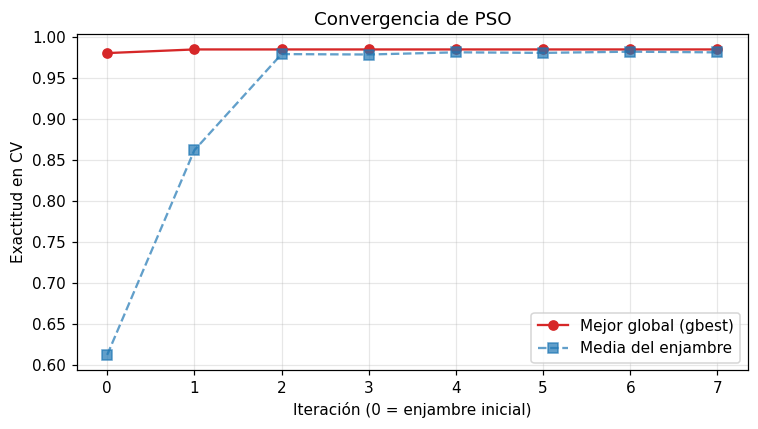

In [7]:
# Curva de convergencia
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist["gbest_fit"], "o-", label="Mejor global (gbest)", color="tab:red")
ax.plot(hist["mean_fit"], "s--", label="Media del enjambre", color="tab:blue", alpha=0.7)
ax.set_xlabel("Iteración (0 = enjambre inicial)")
ax.set_ylabel("Exactitud en CV")
ax.set_title("Convergencia de PSO")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 6. Visualización del enjambre sobre el paisaje de aptitud

Como el problema tiene solo 2 hiperparámetros, podemos calcular la aptitud sobre una malla y **ver cómo el enjambre se desplaza** hacia la zona de buen desempeño.
(Este cálculo es solo ilustrativo; PSO no necesita el paisaje completo.)

In [8]:
# Paisaje de aptitud (malla 20x20 = 400 evaluaciones, solo para graficar)
n_g = 20
gc = np.linspace(LB[0], UB[0], n_g)
gg = np.linspace(LB[1], UB[1], n_g)
paisaje = np.zeros((n_g, n_g))
eval_tmp = Evaluador(X_train, y_train, cv)
for i, lg in enumerate(gg):
    for j, lc in enumerate(gc):
        paisaje[i, j] = eval_tmp(np.array([lc, lg]))
print("Paisaje calculado. Máximo en la malla:", paisaje.max().round(4))

Paisaje calculado. Máximo en la malla: 0.9866


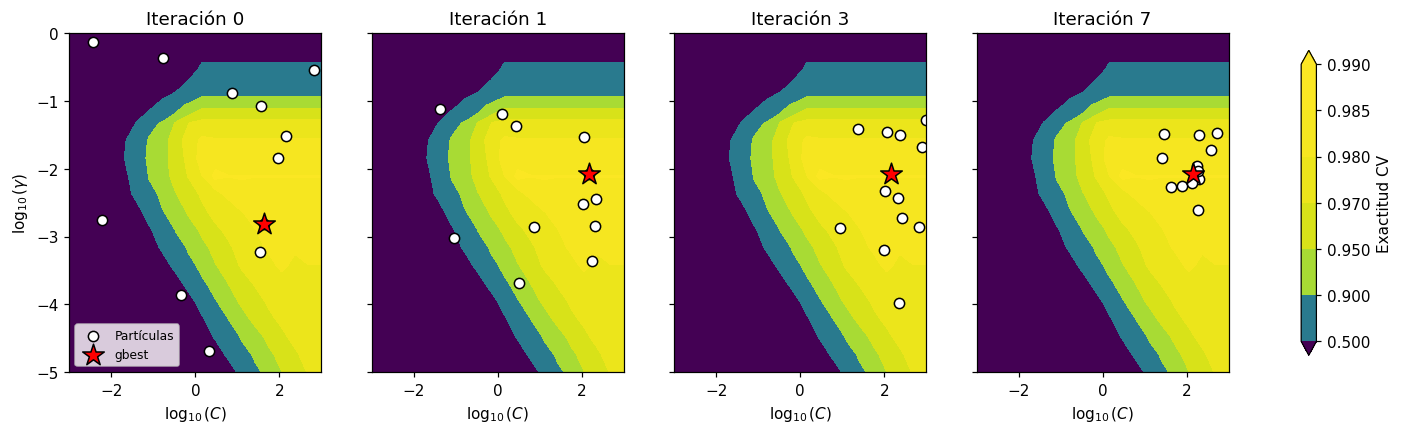

In [9]:
# Posición del enjambre en distintas iteraciones
iters = [0, 1, 3, len(hist["pos"]) - 1]
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharey=True)
for ax, it in zip(axes, iters):
    im = ax.contourf(gc, gg, paisaje, levels=[0.5, 0.9, 0.95, 0.97, 0.98, 0.985, 0.99],
                     cmap="viridis", extend="both")
    P = hist["pos"][it]
    ax.scatter(P[:, 0], P[:, 1], c="white", edgecolors="k", s=45, label="Partículas")
    gb = hist["gbest_pos"][it]
    ax.scatter(gb[0], gb[1], marker="*", c="red", s=220, edgecolors="k", label="gbest")
    ax.set_title(f"Iteración {it}")
    ax.set_xlabel(r"$\log_{10}(C)$")
axes[0].set_ylabel(r"$\log_{10}(\gamma)$")
axes[0].legend(loc="lower left", fontsize=8)
fig.colorbar(im, ax=axes, label="Exactitud CV", shrink=0.9)
plt.show()

## 7. Comparación con *Grid Search* y *Random Search*

Para saber si PSO aporta valor, lo comparamos con dos métodos clásicos usando **el mismo presupuesto de evaluaciones** que gastó PSO.

In [10]:
# --- Random Search con el mismo número de evaluaciones que PSO ---
rng = np.random.default_rng(SEED)
fit_rs = Evaluador(X_train, y_train, cv)
t0 = time.time()
cand = rng.uniform(LB, UB, (evals_pso, DIM))
scores_rs = np.array([fit_rs(x) for x in cand])
x_rs, f_rs, t_rs = cand[scores_rs.argmax()], scores_rs.max(), time.time() - t0

# --- Grid Search con ~ el mismo presupuesto (malla cuadrada) ---
lado = int(np.sqrt(evals_pso))
fit_gs = Evaluador(X_train, y_train, cv)
t0 = time.time()
malla = [(a, b) for a in np.linspace(LB[0], UB[0], lado) for b in np.linspace(LB[1], UB[1], lado)]
scores_gs = np.array([fit_gs(np.array(p)) for p in malla])
x_gs, f_gs, t_gs = np.array(malla[scores_gs.argmax()]), scores_gs.max(), time.time() - t0

print("Comparación hecha con presupuesto similar de evaluaciones.")

Comparación hecha con presupuesto similar de evaluaciones.


In [11]:
def test_acc(x):
    m = make_pipeline(StandardScaler(), SVC(kernel="rbf", **decode(x))).fit(X_train, y_train)
    return accuracy_score(y_test, m.predict(X_test))

# Línea base: hiperparámetros por defecto de scikit-learn (C=1, gamma='scale')
base = make_pipeline(StandardScaler(), SVC()).fit(X_train, y_train)
base_cv = cross_val_score(make_pipeline(StandardScaler(), SVC()), X_train, y_train, cv=cv).mean()
base_test = accuracy_score(y_test, base.predict(X_test))

tabla = pd.DataFrame([
    ["SVM por defecto",  1.0,               "scale",              round(base_cv, 4), round(base_test, 4), 1,                None],
    ["Grid Search",      decode(x_gs)["C"], decode(x_gs)["gamma"], round(f_gs, 4),    round(test_acc(x_gs), 4), fit_gs.n_evals, round(t_gs, 1)],
    ["Random Search",    decode(x_rs)["C"], decode(x_rs)["gamma"], round(f_rs, 4),    round(test_acc(x_rs), 4), fit_rs.n_evals, round(t_rs, 1)],
    ["PSO (enjambre)",   mejores_hp["C"],   mejores_hp["gamma"],   round(gbest_fit, 4), round(test_acc(gbest), 4), evals_pso, round(tiempo_pso, 1)],
], columns=["Método", "C", "gamma", "Exactitud CV", "Exactitud TEST", "Evaluaciones", "Tiempo (s)"])
tabla

,Método,C,gamma,Exactitud CV,Exactitud TEST,Evaluaciones,Tiempo (s)
0,SVM por defecto,1.000000,scale,0.9792,0.9800,1,NaN
1,Grid Search,31.622777,0.003162,0.9822,0.9844,81,52.1
2,Random Search,423.602710,0.007222,0.9844,0.9822,96,61.9
3,PSO (enjambre),144.469617,0.008518,0.9851,0.9822,96,44.8


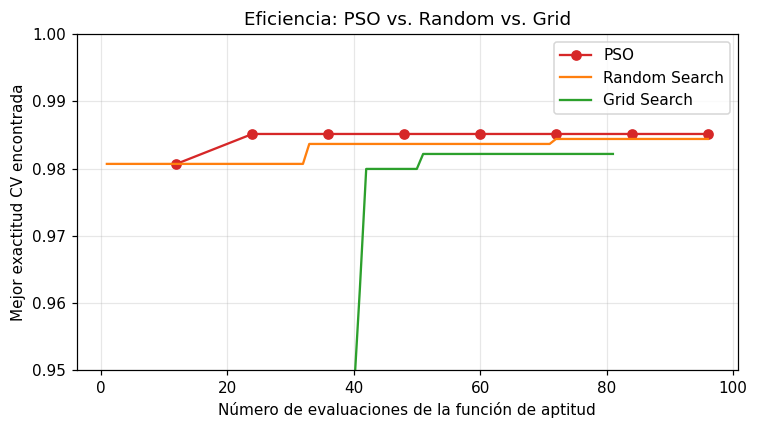

In [12]:
# Convergencia comparada: mejor valor encontrado vs. número de evaluaciones
def mejor_acumulado(v): return np.maximum.accumulate(v)

# PSO: mejor gbest por iteración -> lo expresamos por evaluaciones (12 por iteración + 12 iniciales)
n_p = pso.n
evals_x = [n_p * (k + 1) for k in range(len(hist["gbest_fit"]))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(evals_x, hist["gbest_fit"], "o-", color="tab:red", label="PSO")
ax.plot(range(1, len(scores_rs) + 1), mejor_acumulado(scores_rs), color="tab:orange", label="Random Search")
ax.plot(range(1, len(scores_gs) + 1), mejor_acumulado(scores_gs), color="tab:green", label="Grid Search")
ax.set_ylim(0.95, 1.0)
ax.set_xlabel("Número de evaluaciones de la función de aptitud")
ax.set_ylabel("Mejor exactitud CV encontrada")
ax.set_title("Eficiencia: PSO vs. Random vs. Grid")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### 7.1 Robustez: repetición con varias semillas
Un solo experimento puede favorecer a un método por azar. Repetimos PSO y Random Search con **5 semillas distintas** y el mismo presupuesto (~ 110 evaluaciones).
*(Esta celda tarda unos minutos.)*

In [13]:
resultados = []
for s in range(5):
    f_p = Evaluador(X_train, y_train, cv)
    _, fp, _ = PSO(f_p, LB, UB, n_particles=10, n_iter=10, seed=100 + s, verbose=False).run()

    f_r = Evaluador(X_train, y_train, cv)
    rng_s = np.random.default_rng(100 + s)
    fr = max(f_r(x) for x in rng_s.uniform(LB, UB, (f_p.n_evals, DIM)))

    resultados.append({"semilla": 100 + s, "PSO": round(fp, 4), "Random": round(fr, 4), "evals": f_p.n_evals})

df_multi = pd.DataFrame(resultados)
display(df_multi)
print(f"\nMedia PSO   : {df_multi['PSO'].mean():.4f} ± {df_multi['PSO'].std():.4f}")
print(f"Media Random: {df_multi['Random'].mean():.4f} ± {df_multi['Random'].std():.4f}")

,semilla,PSO,Random,evals
0,100,0.9874,0.9866,110
1,101,0.9851,0.9851,70
2,102,0.9851,0.9851,90
3,103,0.9851,0.9844,90
4,104,0.9851,0.9866,80



Media PSO   : 0.9856 ± 0.0010
Media Random: 0.9856 ± 0.0010


## 8. Evaluación final en datos de prueba

In [14]:
# Modelo final: reentrenamos con TODO el conjunto de entrenamiento y los hiperparámetros de PSO
modelo_final = make_pipeline(StandardScaler(), SVC(kernel="rbf", **mejores_hp)).fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

print(f"Exactitud en PRUEBA (modelo con PSO)      : {accuracy_score(y_test, y_pred):.4f}")
print(f"Exactitud en PRUEBA (SVM por defecto)     : {base_test:.4f}\n")
print(classification_report(y_test, y_pred, digits=3))

Exactitud en PRUEBA (modelo con PSO)      : 0.9822
Exactitud en PRUEBA (SVM por defecto)     : 0.9800

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        45
           1      0.957     0.978     0.968        46
           2      1.000     1.000     1.000        44
           3      1.000     1.000     1.000        46
           4      0.957     0.978     0.967        45
           5      1.000     0.978     0.989        46
           6      0.978     1.000     0.989        45
           7      0.957     1.000     0.978        45
           8      1.000     0.930     0.964        43
           9      0.977     0.956     0.966        45

    accuracy                          0.982       450
   macro avg      0.983     0.982     0.982       450
weighted avg      0.983     0.982     0.982       450



## 9. Conclusiones

1. **Hyperparameter tuning como problema de optimización:** se formuló como la maximización de una función *caja negra* (exactitud en CV) sobre el espacio $[\log_{10}C, \log_{10}\gamma]$.
2. **El ciclo del enjambre se cumple completo:** representación (vector en escala log) → inicialización aleatoria → aptitud por CV → actualización con inercia + *pbest* + *gbest* → evolución iterativa → parada por máximo de iteraciones o estancamiento.
3. **El paisaje de aptitud es difícil para un método ingenuo:** hay grandes regiones con exactitud muy baja (≈ 0.2) y una *cresta* estrecha de buenas soluciones. El enjambre, al compartir información, se concentra rápidamente en esa cresta (ver figura de la sección 6).
4. **PSO frente a métodos clásicos (lectura honesta de los resultados):** con el mismo presupuesto de evaluaciones, PSO alcanzó una aptitud igual o ligeramente superior a Grid y Random Search en la corrida principal, pero **en la repetición con 5 semillas su media empató con la de Random Search**. Esto es esperable: con solo 2 hiperparámetros y una meseta amplia de soluciones buenas, el muestreo aleatorio ya es muy competitivo. La ventaja de PSO aparece cuando el espacio crece (más hiperparámetros, regiones buenas más estrechas), porque el enjambre **aprovecha lo aprendido** y la malla crece exponencialmente.
5. **Limitaciones:** PSO tiene sus propios hiperparámetros ($w$, $c_1$, $c_2$, tamaño del enjambre); es estocástico (conviene repetir con varias semillas); y con un solo conjunto de CV puede haber ligero sobreajuste a la validación, por eso se reporta también la exactitud en un conjunto de prueba independiente.

### Extensión: hiperparámetros enteros y categóricos
Para modelos con hiperparámetros mixtos (p. ej. `RandomForest`) solo hay que cambiar la función `decode`: la partícula sigue siendo un vector real y se convierte al tipo adecuado:

```python
def decode_rf(x):
    return {
        "n_estimators":      int(round(x[0])),          # entero en [20, 300]
        "max_depth":         int(round(x[1])),          # entero en [2, 30]
        "min_samples_split": int(round(x[2])),          # entero en [2, 20]
        "max_features":      float(x[3]),               # continuo en [0.1, 1.0]
        "criterion":         ["gini", "entropy"][int(x[4] > 0.5)],   # categórico
    }
```
El resto del algoritmo (inicialización, movimiento, evolución) no cambia.

### Referencias
- Kennedy, J. & Eberhart, R. (1995). *Particle Swarm Optimization*. Proc. IEEE International Conference on Neural Networks.
- Shi, Y. & Eberhart, R. (1998). *A Modified Particle Swarm Optimizer* (peso de inercia).
- Bergstra, J. & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. JMLR.
- Documentación de scikit-learn: https://scikit-learn.org/stable/modules/grid_search.html